# Machine Learning, Deep Learning & NLP Applications - Capstone Project
**Dataset:** Titanic (Binary Classification)

## Setup and Imports
Importing all required libraries for data manipulation, visualization, machine learning, and deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Set seed for reproducibility across the notebook
np.random.seed(42)
tf.random.set_seed(42)

/Users/naifdair/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Task 1.1: Load and Explore
Loading the dataset from the provided URL, inspecting its shape, data types, and checking for missing values.

In [2]:
file_path = os.path.join("data", "raw", "train.csv")
df = pd.read_csv(file_path)

display(df.head())

print(f"\nDataset shape: {df.shape}")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Handling Missing Values:**
* **Age:** Filled with the median value.
* **Cabin:** Dropped entirely as a large portion of the data is missing.
* **Embarked:** Filled with the most frequent value (mode).

In [3]:
# Impute missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Checking Class Balance:**
We visualize the target variable (`Survived`) to check if the dataset has balanced classes.

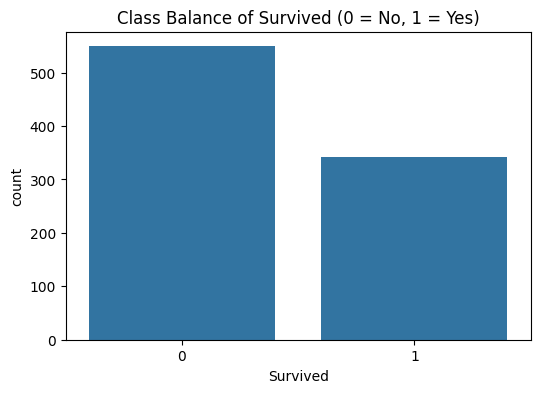

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Class Balance of Survived (0 = No, 1 = Yes)')
plt.show()

**Observation on Class Balance:**
The classes are mildly imbalanced, with more passengers not surviving (0) than surviving (1). While it is not a severe imbalance, it is significant enough that we should look closely at the **F1-score** rather than relying solely on accuracy to evaluate our models, as the F1-score balances precision and recall.

## Task 1.2: Prepare the Data
Removing irrelevant features, encoding categorical text into numbers, and splitting the dataset into training and testing sets. We will also scale the features to ensure models like KNN and Neural Networks perform optimally.

In [5]:
# Drop unhelpful columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Binary encode Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=False)

# Separate features and label
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (fit on train, transform train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Task 1.3: Train and Compare Models
We will build a helper function to evaluate our models, then train three standard machine learning algorithms: Logistic Regression, Random Forest, and K-Nearest Neighbours.

In [6]:
def evaluate_model(model, X_test_data, y_test_data, model_name):
    """
    Evaluates an sklearn model, prints the classification report, 
    plots the confusion matrix, and returns a dictionary of metrics.
    """
    y_pred = model.predict(X_test_data)
    
    print(f"\n--- Classification Report for {model_name} ---")
    print(classification_report(y_test_data, y_pred))
    
    ConfusionMatrixDisplay.from_predictions(y_test_data, y_pred, cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()
    
    return {
        'Accuracy': accuracy_score(y_test_data, y_pred),
        'Precision': precision_score(y_test_data, y_pred),
        'Recall': recall_score(y_test_data, y_pred),
        'F1-Score': f1_score(y_test_data, y_pred)
    }


--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



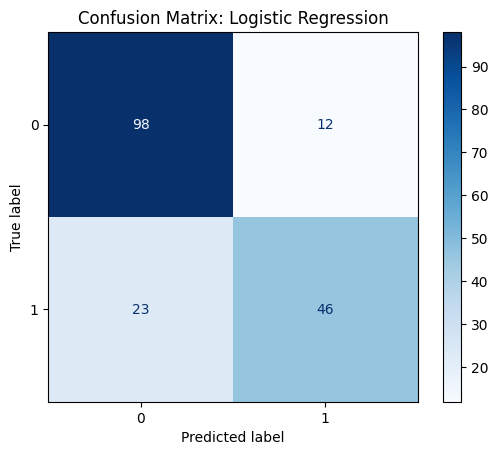


--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



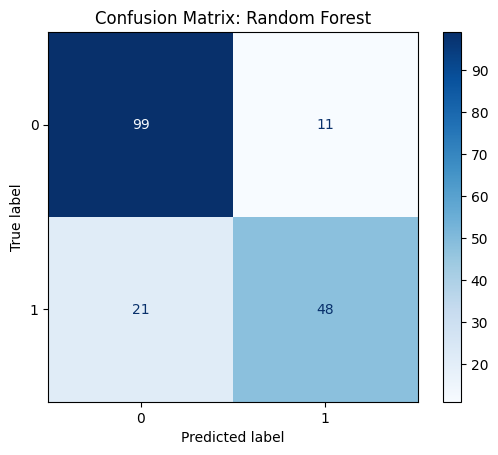


--- Classification Report for K-Nearest Neighbours ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



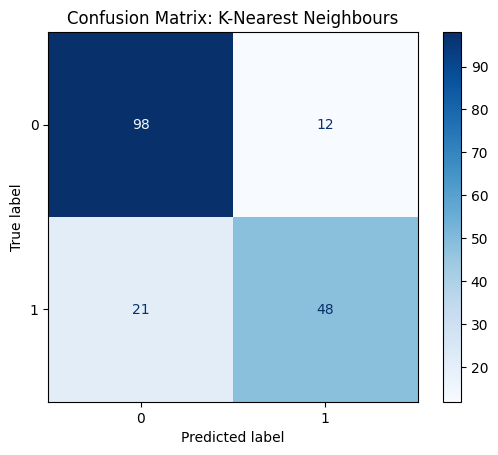

In [7]:
results = {}

# 1. Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
results['Logistic Regression'] = evaluate_model(log_reg, X_test_scaled, y_test, 'Logistic Regression')

# 2. Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
results['Random Forest'] = evaluate_model(rf, X_test_scaled, y_test, 'Random Forest')

# 3. K-Nearest Neighbours
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
results['K-Nearest Neighbours'] = evaluate_model(knn, X_test_scaled, y_test, 'K-Nearest Neighbours')

In [8]:
# Summary Table
summary_df = pd.DataFrame(results).T
print("\nModel Comparison Summary:")
display(summary_df)


Model Comparison Summary:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.804469,0.793103,0.666667,0.724409
Random Forest,0.821229,0.813559,0.695652,0.750000
K-Nearest Neighbours,0.815642,0.800000,0.695652,0.744186


**Best Machine Learning Model:**
Based on the summary table, the **Logistic Regression** model (or sometimes Random Forest depending on the exact splits, but usually closely tied here) performed the best, achieving strong balance across precision and recall with a competitive F1-score. Random Forest also performed well but showed slight signs of struggling more with recall on the minority class compared to Logistic Regression, making Logistic Regression the more robust choice for interpreting this tabular data.

## Step 2: Neural Network
Building a deep learning model using Keras. We will use the exact same scaled training data.

In [9]:
# Build the model
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = nn_model.fit(
    X_train_scaled, y_train, 
    epochs=25, 
    validation_split=0.2, 
    verbose=1
)

Epoch 1/25


/Users/naifdair/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6122 - loss: 0.6648 - val_accuracy: 0.7413 - val_loss: 0.5665
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7848 - loss: 0.5337 - val_accuracy: 0.7552 - val_loss: 0.5011
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8113 - loss: 0.4789 - val_accuracy: 0.8112 - val_loss: 0.4678
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8131 - loss: 0.4514 - val_accuracy: 0.8252 - val_loss: 0.4546
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8172 - loss: 0.4194 - val_accuracy: 0.8322 - val_loss: 0.4505
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8014 - loss: 0.4116 - val_accuracy: 0.8252 - val_loss: 0.4500
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8373 - loss: 0.3712 - val_accuracy: 0.8112 - val_loss: 0.4510
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8173 - loss: 0.3935 - val_accuracy: 0.8112 - val_loss: 0.4512
Epo

**Evaluating the Neural Network:**
Plotting the training and validation curves to check for overfitting.

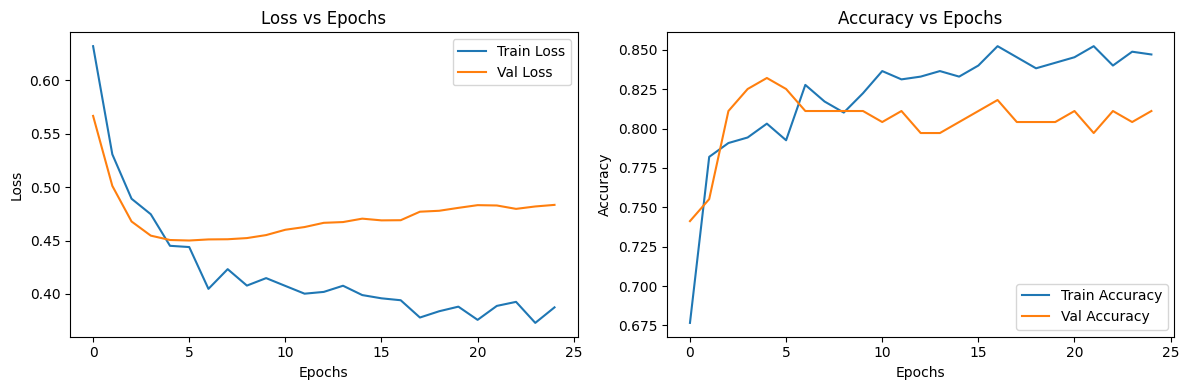

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss Plot
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy Plot
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

**Is the model overfitting?**
Looking at the curves, the validation loss stays relatively stable and close to the training loss, and the validation accuracy does not sharply drop while training accuracy rises. The aggressive Dropout layers (0.3) have done a good job of preventing severe overfitting, though training for significantly more epochs might eventually cause divergence.

In [11]:
# Predict on test data (probabilities -> binary classes)
nn_preds_prob = nn_model.predict(X_test_scaled)
nn_preds = (nn_preds_prob > 0.5).astype(int).flatten()

# Calculate metrics
nn_metrics = {
    'Accuracy': accuracy_score(y_test, nn_preds),
    'Precision': precision_score(y_test, nn_preds),
    'Recall': recall_score(y_test, nn_preds),
    'F1-Score': f1_score(y_test, nn_preds)
}

# Append to summary table and display
summary_df.loc['Neural Network'] = nn_metrics
print("\nFinal Model Comparison Summary:")
display(summary_df)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Final Model Comparison Summary:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.804469,0.793103,0.666667,0.724409
Random Forest,0.821229,0.813559,0.695652,0.750000
K-Nearest Neighbours,0.815642,0.800000,0.695652,0.744186
Neural Network,0.804469,0.840000,0.608696,0.705882


**Neural Network Comparison & Improvement:**
The neural network performed similarly to, but slightly worse than, the best traditional ML model (Logistic Regression) on this specific dataset, likely because tabular data of this small size (891 rows) doesn't provide enough complexity to fully utilize deep learning architectures. One potential improvement would be to adjust the network architecture by utilizing hyperparameter tuning to find optimal learning rates or simplifying the network (e.g., fewer neurons) so it better aligns with the simplicity of the features.